Saving Titanic-Dataset.csv to Titanic-Dataset.csv
First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123   

/tmp/ipykernel_6392/933031348.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_6392/933031348.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

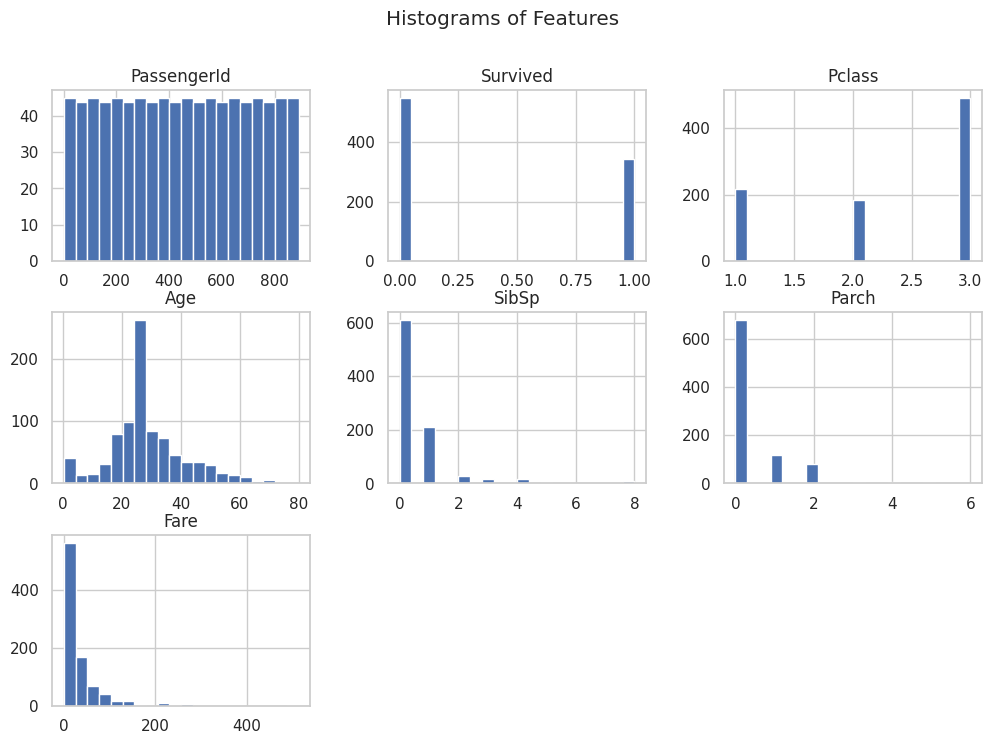

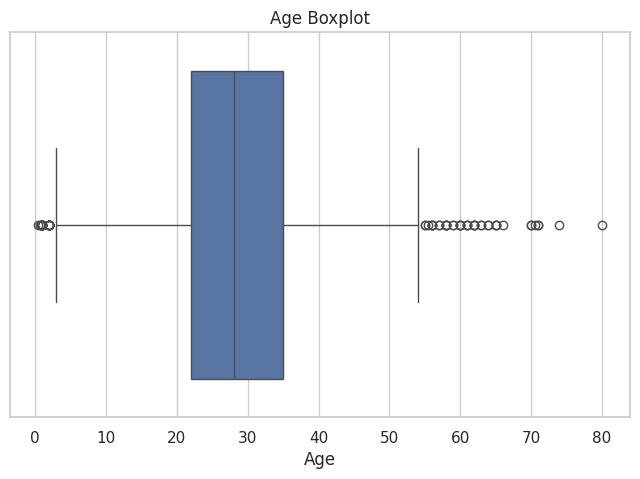

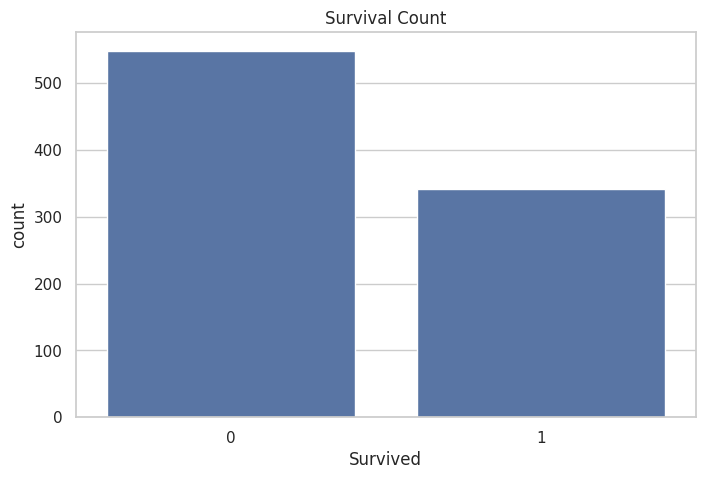

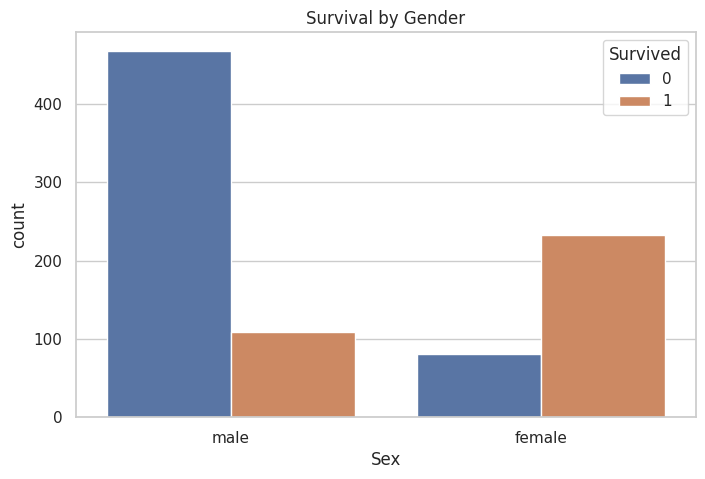

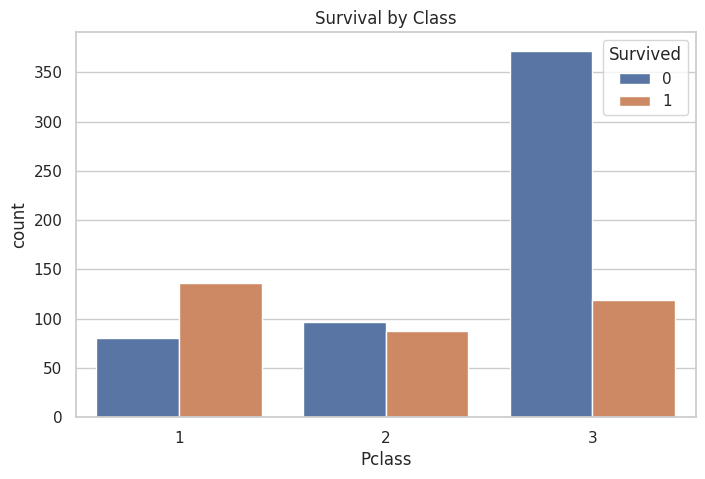

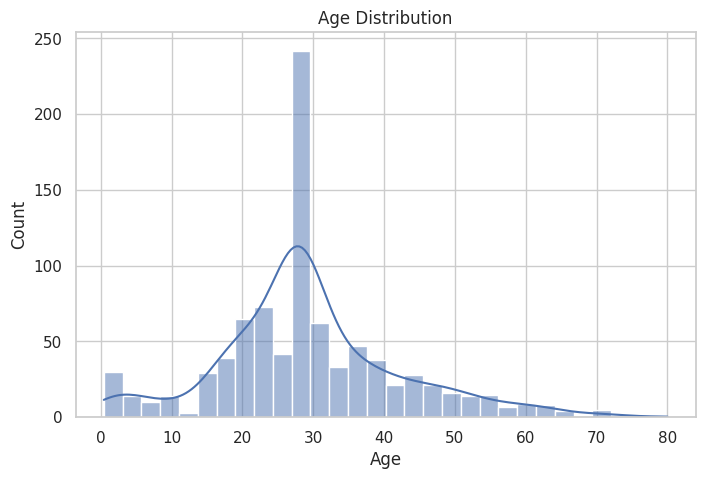

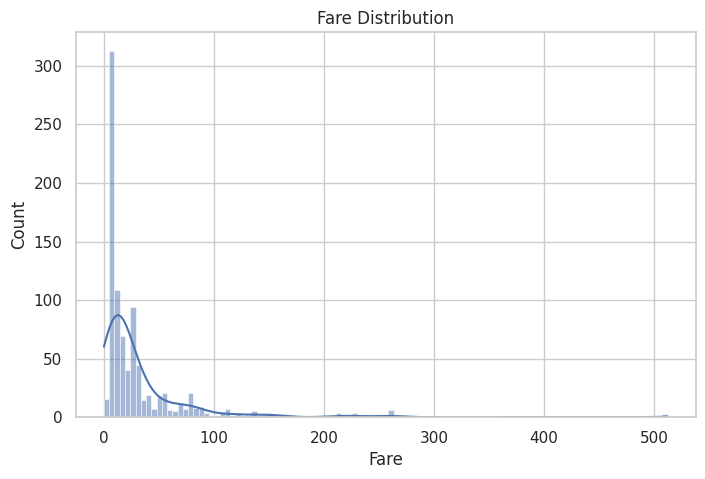

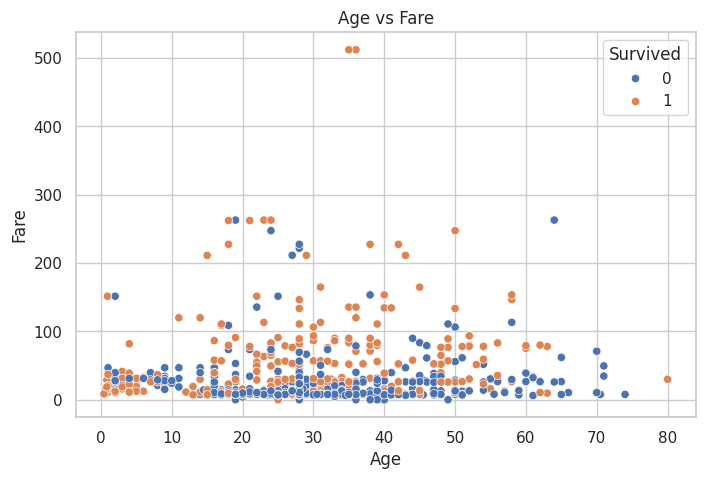

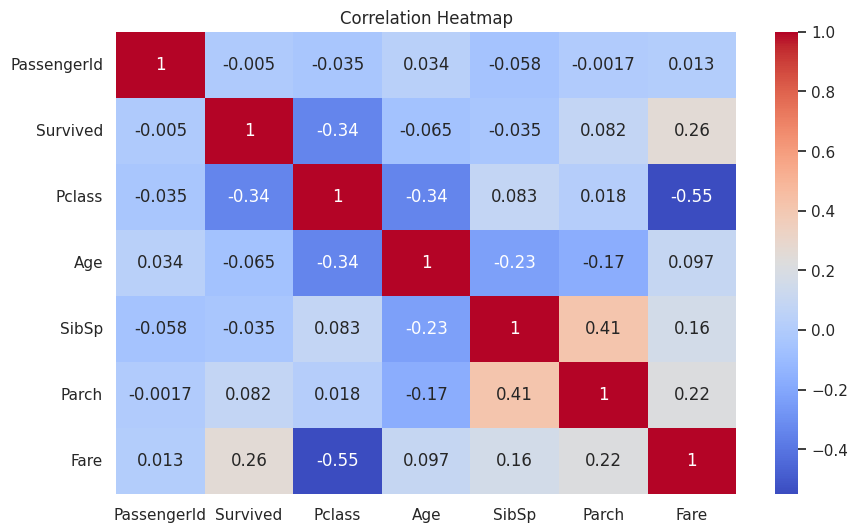

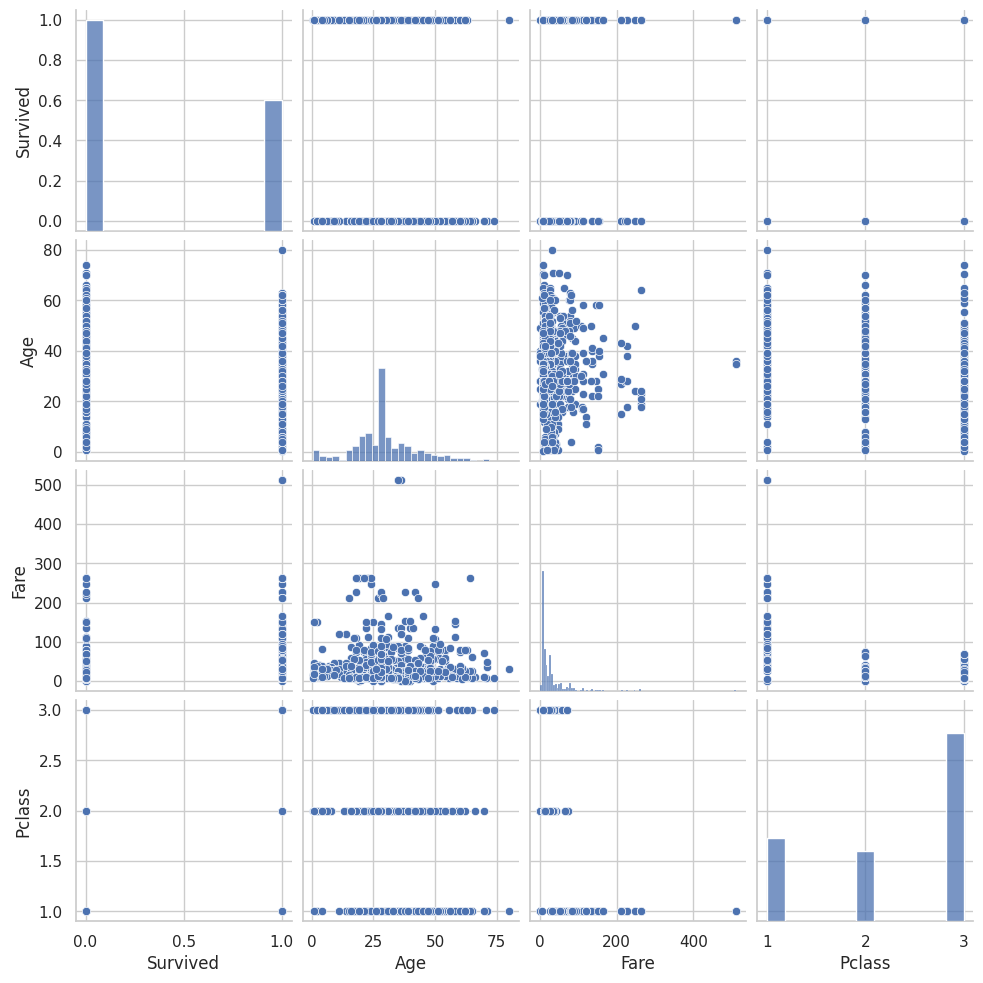


Basic Insights:
Survival Rate: 38.38%

Survival by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [1]:
# ==============================
#  1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# ==============================
#  2. UPLOAD DATASET
# ==============================
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# ==============================
#  3. BASIC INFO
# ==============================
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nShape:", df.shape)

# ==============================
#  4. MISSING VALUES
# ==============================
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values (important for Titanic)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
df.drop('Cabin', axis=1, inplace=True)

# ==============================
#  5. SUMMARY STATS
# ==============================
print("\nSummary Statistics:")
print(df.describe())

# ==============================
#  6. HISTOGRAMS
# ==============================
df.hist(bins=20, figsize=(12,8))
plt.suptitle("Histograms of Features")
plt.show()

# ==============================
#  7. BOXPLOT (OUTLIERS)
# ==============================
plt.figure()
sns.boxplot(x=df['Age'])
plt.title("Age Boxplot")
plt.show()

# ==============================
#  8. COUNT PLOTS (CATEGORICAL)
# ==============================

# Survival count
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# Gender vs Survival
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Passenger Class vs Survival
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Class")
plt.show()

# ==============================
#  9. DISTRIBUTION PLOTS
# ==============================
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(df['Fare'], kde=True)
plt.title("Fare Distribution")
plt.show()

# ==============================
#  10. SCATTER PLOT
# ==============================
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare")
plt.show()

# ==============================
#  11. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==============================
#  12. PAIRPLOT
# ==============================
sns.pairplot(df[['Survived','Age','Fare','Pclass']])
plt.show()

# ==============================
#  13. BASIC INSIGHTS
# ==============================
print("\nBasic Insights:")

# Survival rate
survival_rate = df['Survived'].mean()
print(f"Survival Rate: {round(survival_rate*100,2)}%")

# Gender survival
print("\nSurvival by Gender:")
print(df.groupby('Sex')['Survived'].mean())

# Class survival
print("\nSurvival by Class:")
print(df.groupby('Pclass')['Survived'].mean())